In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
import pylab as plt
import numpy as np
from loguru import logger

from stable_baselines3 import PPO

In [4]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler

from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import run_method
from vimms_gym.common import METHOD_TOPN, METHOD_PPO
from vimms_gym.visualisation import plot_N, plot_ms1_ms2_counts, plot_action_hist, plot_action_probs, plot_reward_probs

# 1. Parameters

In [5]:
n_chemicals = (2000, 5000)
mz_range = (70, 1000)
rt_range = (0, 1440)
intensity_range = (1E4, 1E20)

In [6]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [7]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [8]:
mzml_filename = '../fullscan_QCB.mzML'
samplers = None
samplers_pickle = 'samplers_fullscan_QCB.mzML.p'
if exists(samplers_pickle):
    logger.info('Loaded %s' % samplers_pickle)
    samplers = load_obj(samplers_pickle)
    mz_sampler = samplers['mz']
    ri_sampler = samplers['rt_intensity']
    cr_sampler = samplers['chromatogram']
else:
    logger.info('Creating samplers from %s' % mzml_filename)
    mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
    ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                           min_log_intensity=min_log_intensity,
                                           max_log_intensity=max_log_intensity)
    roi_params = RoiBuilderParams(min_roi_length=3, at_least_one_point_above=1000)
    cr_sampler = MZMLChromatogramSampler(mzml_filename, roi_params=roi_params)
    samplers = {
        'mz': mz_sampler,
        'rt_intensity': ri_sampler,
        'chromatogram': cr_sampler
    }
    save_obj(samplers, samplers_pickle)

2022-06-10 14:23:30.446 | INFO     | __main__:<module>:5 - Loaded samplers_fullscan_QCB.mzML.p


In [9]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': GaussianChromatogramSampler(),
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [10]:
max_peaks = 200
in_dir = 'results'

In [11]:
n_eval_episodes = 1
deterministic = True

# 2. Evaluation

## Generate some chemical sets

In [12]:
set_log_level_warning()

1

In [13]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0


## Run different methods

In [14]:
eval_dir = 'visualisation'

In [15]:
for chems in chem_list:
    print(len(chems))

4887


In [16]:
max_peaks

200

In [17]:
out_dir = eval_dir
in_dir, out_dir

('results', 'visualisation')

In [18]:
all_results = {}

In [19]:
env_name = 'DDAEnv'

### Run PPO

In [20]:
method = METHOD_PPO

In [21]:
model_name = 'PPO'

In [22]:
effective_rt_tol = rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [23]:
fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
model = PPO.load(fname)

In [24]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, model=model, print_eval=True, print_reward=True)


Episode 0 (4887 chemicals)
steps	 500 	total rewards	 32.999747954313264
steps	 1000 	total rewards	 136.0448120941814
steps	 1500 	total rewards	 295.33685828379635
steps	 2000 	total rewards	 457.0724285759821
steps	 2500 	total rewards	 629.2645482493278
steps	 3000 	total rewards	 793.4891408782648
steps	 3500 	total rewards	 954.8077484534754
steps	 4000 	total rewards	 1009.9349992451705
steps	 4500 	total rewards	 1081.79066429954
steps	 5000 	total rewards	 1132.148722315083
steps	 5500 	total rewards	 1177.2044410928438
Finished after 5581 timesteps with total reward 1182.0194907396967
{'coverage_prop': '0.861', 'intensity_prop': '0.623', 'ms1/ms2 ratio': '0.409', 'efficiency': '1.062', 'TP': '1302', 'FP': '922', 'FN': '2663', 'precision': '0.585', 'recall': '0.328', 'f1': '0.421'}


In [25]:
ppo_result = results[0]
ppo_result

### Run Top-N

In [26]:
method = METHOD_TOPN

In [27]:
topN_N = 20
topN_rt_tol = 30

In [28]:
copy_params = dict(params)        
copy_params['env']['rt_tol'] = topN_rt_tol

In [29]:
model = None

In [30]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, N=topN_N, model=model, print_eval=True, print_reward=True)


Episode 0 (4887 chemicals)
steps	 500 	total rewards	 0.9870353116781065
steps	 1000 	total rewards	 122.98366848689238
steps	 1500 	total rewards	 262.88647688728855
steps	 2000 	total rewards	 398.2408959647777
steps	 2500 	total rewards	 538.7875690225642
steps	 3000 	total rewards	 678.2555931273655
steps	 3500 	total rewards	 835.4473240153857
steps	 4000 	total rewards	 895.2330861614738
steps	 4500 	total rewards	 948.4494223398192
steps	 5000 	total rewards	 1020.3128939030601
steps	 5500 	total rewards	 1062.9091913900177
Finished after 5697 timesteps with total reward 1071.601563645207
{'coverage_prop': '0.847', 'intensity_prop': '0.654', 'ms1/ms2 ratio': '0.358', 'efficiency': '0.987', 'TP': '1457', 'FP': '752', 'FN': '2678', 'precision': '0.660', 'recall': '0.352', 'f1': '0.459'}


In [31]:
topN_result = results[0]
topN_result

# 3. Visualisation

## Visualise some results from the first episode

Limit some plots to the first 1000 steps.

In [46]:
limit = 2000

Plot the distribution of N: the number of MS2 scans that follow an MS1 scan

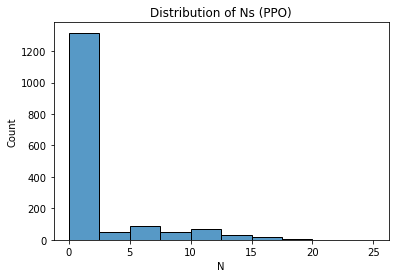

In [47]:
plot_N(ppo_result, bins=10, title='Distribution of Ns (PPO)')

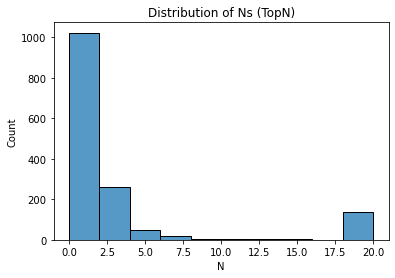

In [48]:
plot_N(topN_result, bins=10, title='Distribution of Ns (TopN)')

Plot the number of MS1 and MS2 scans over time

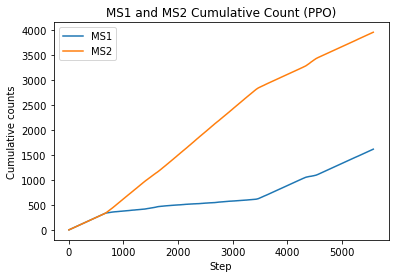

In [49]:
ppo_ms1, ppo_ms2 = plot_ms1_ms2_counts(ppo_result, title='MS1 and MS2 Cumulative Count (PPO)')

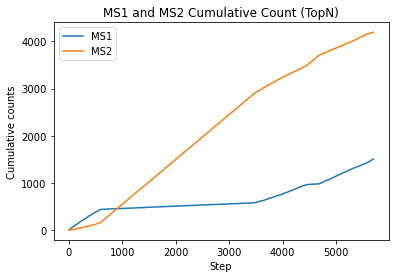

In [50]:
topN_ms1, topN_ms2 = plot_ms1_ms2_counts(topN_result, title='MS1 and MS2 Cumulative Count (TopN)')

Text(0.5, 1.0, 'MS2 Cumulative Counts')

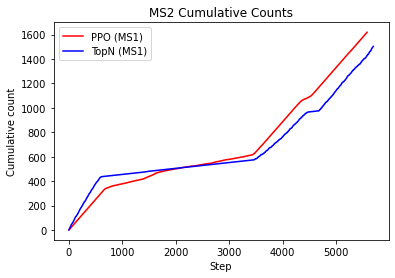

In [51]:
plt.plot(ppo_ms1, 'r-', label='PPO (MS1)')
plt.plot(topN_ms1, 'b-', label='TopN (MS1)')
plt.legend()
plt.ylabel('Cumulative count')
plt.xlabel('Step')
plt.title('MS2 Cumulative Counts')

Plot a histogram of all actions.

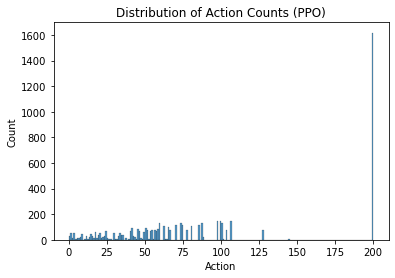

In [52]:
plot_action_hist(ppo_result, bins=200, title='Distribution of Action Counts (PPO)')

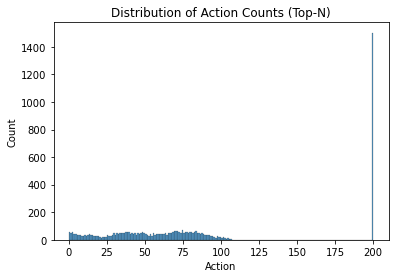

In [53]:
plot_action_hist(topN_result, bins=200, title='Distribution of Action Counts (Top-N)')

Plot a histogram of MS2-actions only

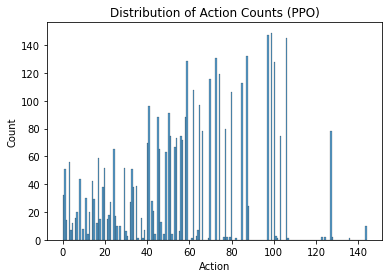

In [54]:
plot_action_hist(ppo_result, ms2_only=True, bins=199, title='Distribution of Action Counts (PPO)')

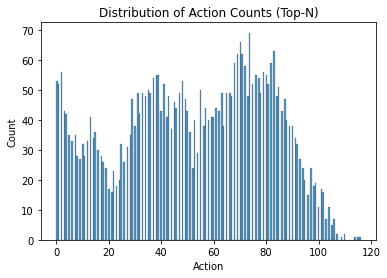

In [55]:
plot_action_hist(topN_result, ms2_only=True, bins=199, title='Distribution of Action Counts (Top-N)')

Show the first few actions

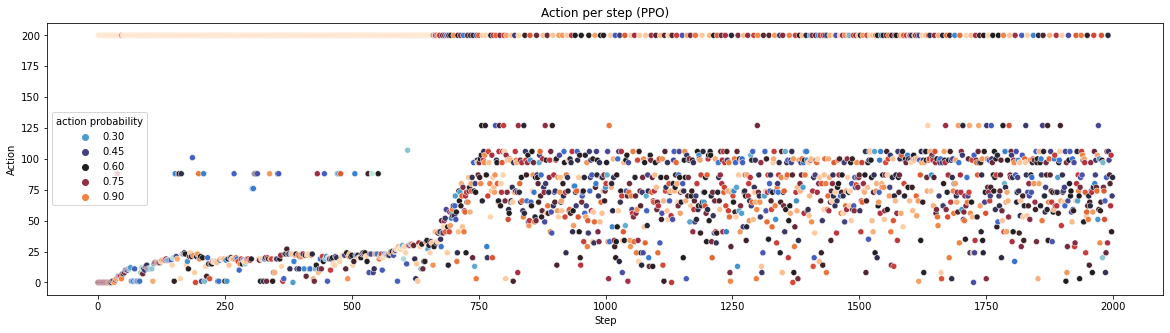

In [56]:
plot_action_probs(ppo_result, limit, max_peaks, title='Action per step (PPO)')

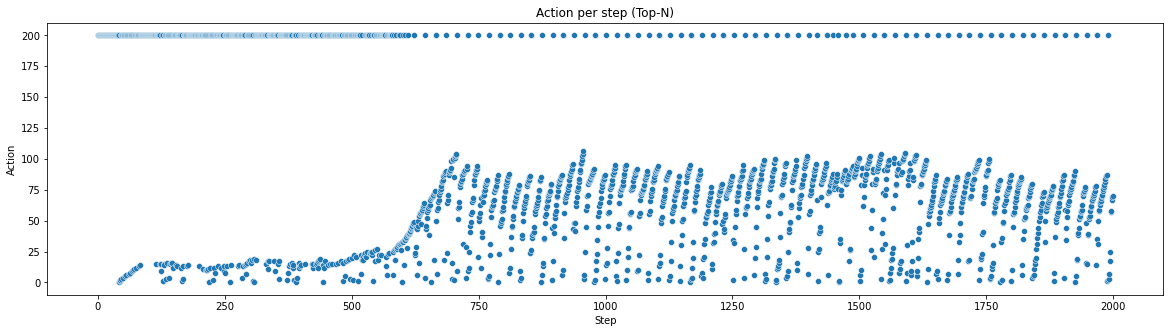

In [57]:
plot_action_probs(topN_result, limit, max_peaks, title='Action per step (Top-N)')

Plot rewards coloured by action probabilities

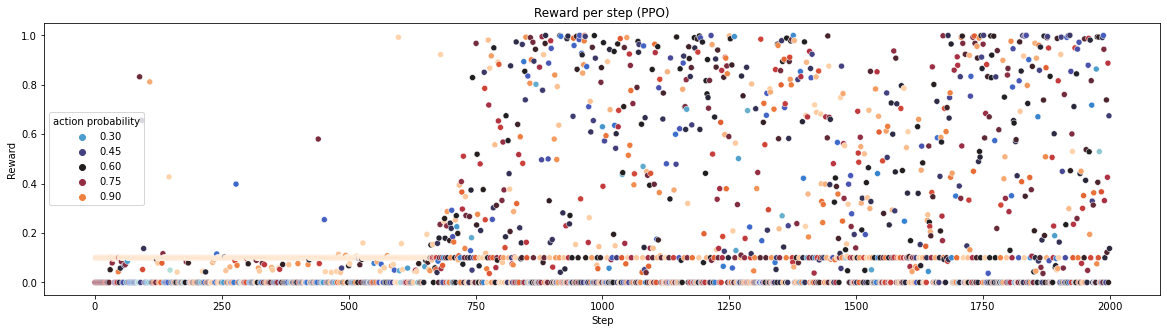

In [58]:
plot_reward_probs(ppo_result, limit, max_peaks, title='Reward per step (PPO)')

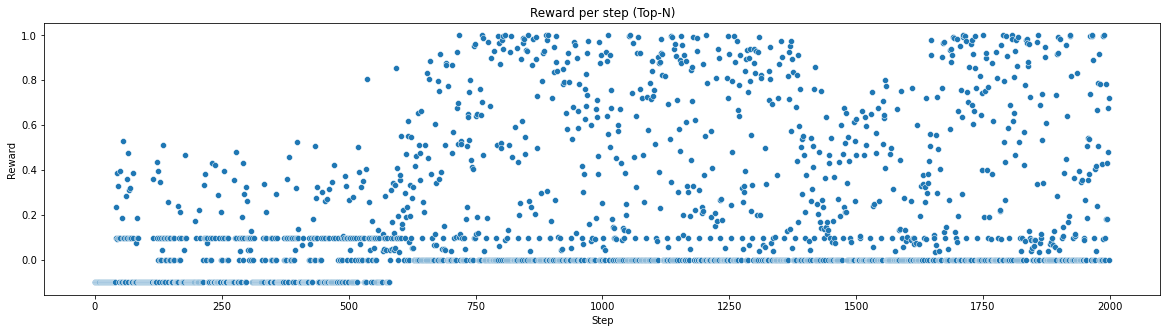

In [59]:
plot_reward_probs(topN_result, limit, max_peaks, title='Reward per step (Top-N)')